<a href="https://colab.research.google.com/github/karanveer-sharma/cdac_project/blob/master/multilayer_preprception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
X = np.array([[0, 0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],[1], [1],[0]])
print("Input :\n", X)
print("Output :\n", y)

Input :
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output :
 [[0]
 [1]
 [1]
 [0]]


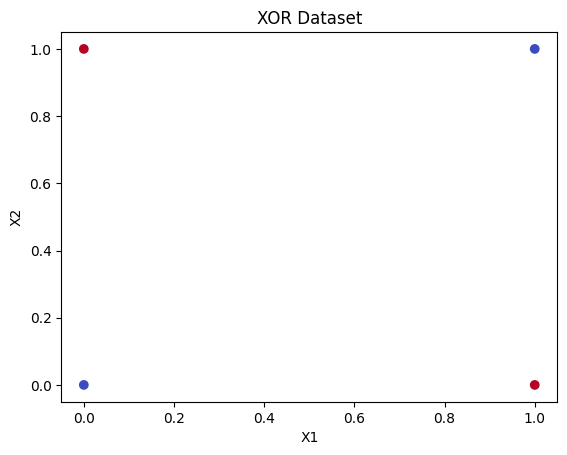

In [3]:
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap="coolwarm")
plt.title("XOR Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [4]:
np.random.seed(42)
input_size=2
hidden_size=3
output_size=1
W1=np.random.randn(input_size, hidden_size)
b1=np.zeros((1, hidden_size))
W2=np.random.randn(hidden_size, output_size)
b2=np.zeros((1, output_size))
print("W1 :\n", W1)
print("W2 :\n", W2)

W1 :
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]
W2 :
 [[ 1.57921282]
 [ 0.76743473]
 [-0.46947439]]


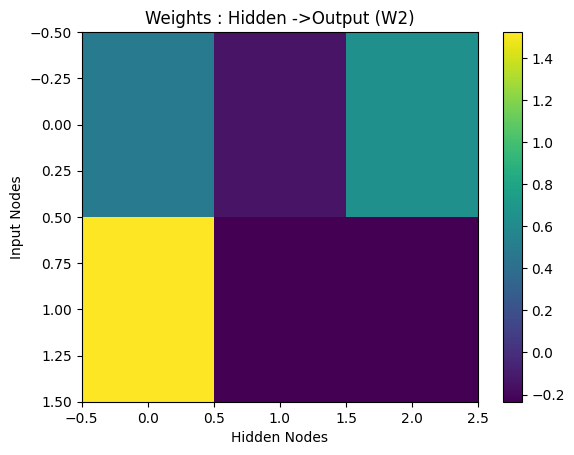

In [5]:
plt.imshow(W1, aspect="auto")
plt.colorbar()
plt.title("Weights : Hidden ->Output (W2)")
plt.xlabel("Hidden Nodes")
plt.ylabel("Input Nodes")
plt.show()

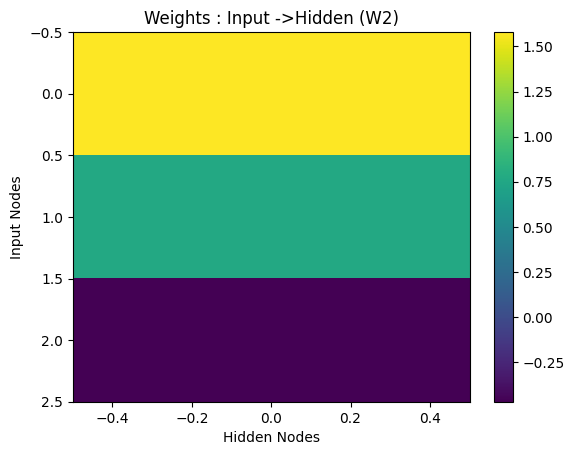

In [6]:
plt.imshow(W2, aspect="auto")
plt.colorbar()
plt.title("Weights : Input ->Hidden (W2)")
plt.xlabel("Hidden Nodes")
plt.ylabel("Input Nodes")
plt.show()


In [7]:
def sigmoid(x):
  return 1/ (1 + np.exp(-x))

In [8]:
def forward(X):
  z1= np.dot(X, W1) + b1
  a1= sigmoid(z1)
  z2= np.dot(a1, W2) + b2
  a2= sigmoid(z2)
  return z1, a1, z2, a2

In [9]:
z1, a1, z2, output= forward(X)
print("hidden layer", a1)
print("output", output)

hidden layer [[0.5        0.5        0.5       ]
 [0.82098421 0.44172766 0.44173171]
 [0.62168683 0.46548889 0.65648939]
 [0.88285454 0.40795696 0.60193917]]
output [[0.71881406]
 [0.80660888]
 [0.73707158]
 [0.80607425]]


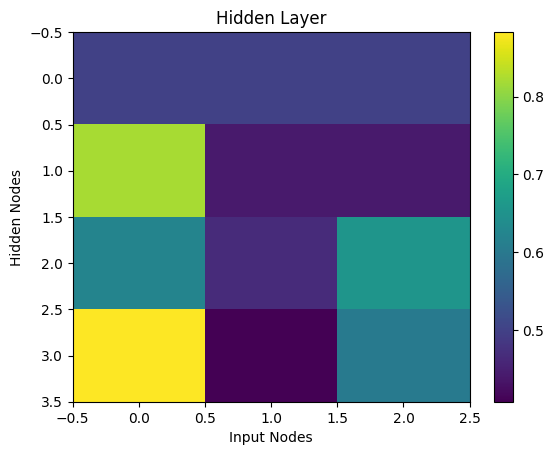

In [10]:
plt.imshow(a1, aspect="auto")
plt.colorbar()
plt.title("Hidden Layer")
plt.xlabel ("Input Nodes")
plt.ylabel("Hidden Nodes")
plt.show()

In [11]:
for i in range(len(X)):
  print(f"Input : {X[i]}")
  print(f"Hidden Activations :{a1[i]}")
  print(f"Output : {output[i]}")


Input : [0 0]
Hidden Activations :[0.5 0.5 0.5]
Output : [0.71881406]
Input : [0 1]
Hidden Activations :[0.82098421 0.44172766 0.44173171]
Output : [0.80660888]
Input : [1 0]
Hidden Activations :[0.62168683 0.46548889 0.65648939]
Output : [0.73707158]
Input : [1 1]
Hidden Activations :[0.88285454 0.40795696 0.60193917]
Output : [0.80607425]


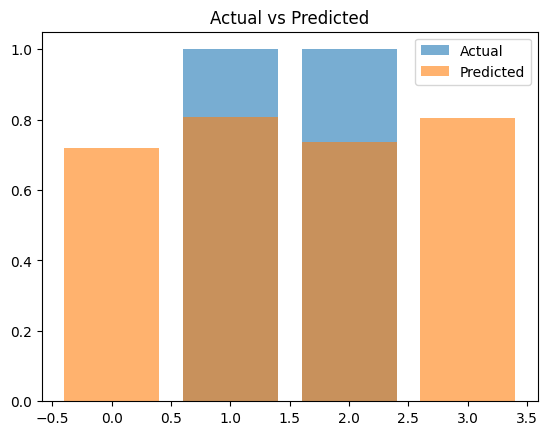

In [12]:
plt.bar(range(len(y)), y.flatten(), alpha= 0.6, label="Actual")
plt.bar(range(len(output)), output.flatten(), alpha= 0.6, label="Predicted")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [13]:
loss= np.mean((y-output)**2)
print("Loss :", loss)

Loss : 0.31824520886068175


In [14]:
learning_rate=0.1
losses=[]
for epoch in range(10000):
  z1, a1, z2, output= forward(X)
  loss= np.mean((y-output)**2)
  losses.append(loss)
  error = y-output
  d_output = error * output * (1-output)
  d_hidden = d_output.dot(W2.T) * a1 *(1- a1)
  W2 += a1.T.dot(d_output) * learning_rate
  W1 += X.T.dot(d_hidden) * learning_rate


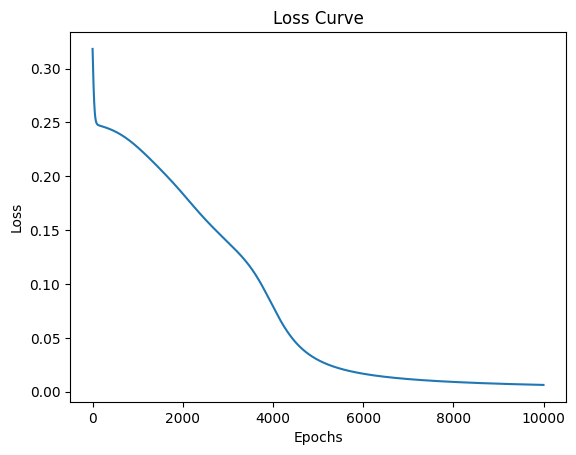

In [16]:
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [17]:
_, _, _, predictions= forward(X)
print("Predictions :\n", predictions)

Predictions :
 [[0.10846339]
 [0.92615799]
 [0.92496146]
 [0.05022337]]


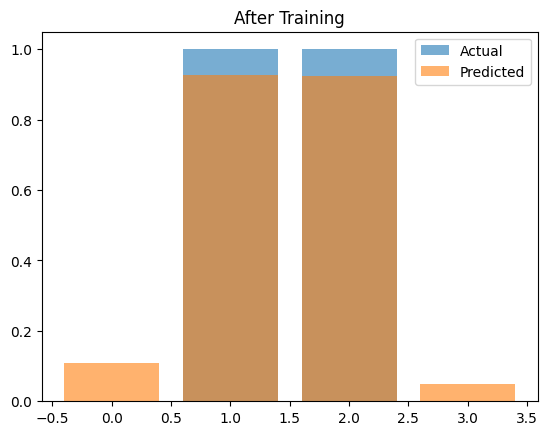

In [18]:
plt.bar(range(len(y)), y.flatten(), alpha= 0.6, label="Actual")
plt.bar(range(len(predictions)), predictions.flatten(), alpha= 0.6, label="Predicted")
plt.legend()
plt.title("After Training")
plt.show()

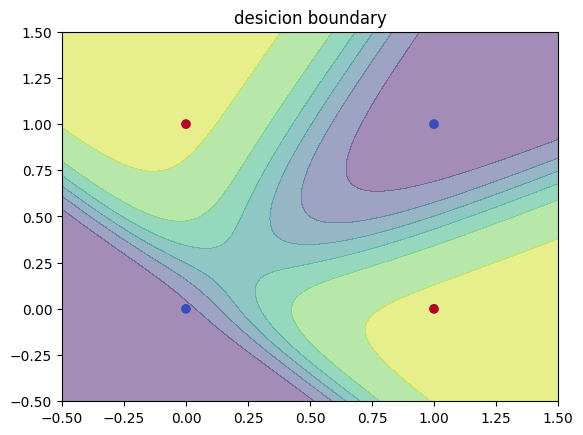

In [19]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
_, _, _, preds = forward(grid)
z = preds.reshape(xx.shape)
plt.contourf(xx, yy, z, alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap="coolwarm")
plt.title("desicion boundary")
plt.show()